In [1]:
# Step 1: Clone Darknet and set up the environment
!git clone https://github.com/AlexeyAB/darknet.git
%cd darknet

Cloning into 'darknet'...
remote: Enumerating objects: 15873, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (21/21), done.
remote: Total 15873 (delta 4), reused 12 (delta 0), pack-reused 15851 (from 1)
Receiving objects: 100% (15873/15873), 14.46 MiB | 14.65 MiB/s, done.
Resolving deltas: 100% (10687/10687), done.
/content/darknet


For GPU Support:
If your device has a compatible NVIDIA GPU, enable GPU and cuDNN acceleration:

In [2]:
!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
!sed -i 's/GPU=0/GPU=1/' Makefile
!sed -i 's/CUDNN=0/CUDNN=1/' Makefile
!sed -i 's/CUDNN_HALF=1/CUDNN_HALF=0/' Makefile
!make

mkdir -p ./obj/
mkdir -p backup
mkdir -p results
chmod +x *.sh
g++ -std=c++11 -std=c++11 -Iinclude/ -I3rdparty/stb/include -DOPENCV `pkg-config --cflags opencv4 2> /dev/null || pkg-config --cflags opencv` -DGPU -I/usr/local/cuda/include/ -DCUDNN -Wall -Wfatal-errors -Wno-unused-result -Wno-unknown-pragmas -fPIC -rdynamic -Ofast -DOPENCV -DGPU -DCUDNN -I/usr/local/cudnn/include -c ./src/image_opencv.cpp -o obj/image_opencv.o
./src/image_opencv.cpp: In function ‘void draw_detections_cv_v3(void**, detection*, int, float, char**, image**, int, int)’:
./src/image_opencv.cpp:945:23: warning: variable ‘rgb’ set but not used []8;;https://gcc.gnu.org/onlinedocs/gcc/Warning-Options.html#index-Wunused-but-set-variable-Wunused-but-set-variable]8;;]
  945 |                 float rgb[3];
      |                       ^~~
./src/image_opencv.cpp: In function ‘void cv_draw_object(image, float*, int, int, int*, float*, int*, int, char**)’:
./src/image_opencv.cpp:1443:14: warning: unused variable ‘bu

In [3]:
#!sed -i 's/OPENCV=0/OPENCV=1/' Makefile
#!sed -i 's/GPU=1/GPU=0/' Makefile
#!sed -i 's/CUDNN=1/CUDNN=0/' Makefile
#!make

In [4]:
!./darknet

usage: ./darknet <function>


In [5]:
import zipfile

zip_path = "/content/battery detection  2.v5i.darknet.zip"  # Adjust the path
output_path = "/content/dataset"
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(output_path)


In [6]:
import os

dataset_path = "/content/dataset"  # Path to extracted dataset
files = os.listdir(dataset_path)
print("Extracted files:", files)

Extracted files: ['train', 'README.dataset.txt', 'valid', 'README.roboflow.txt', 'test']


In [7]:
classes = ["9V", "coincell", "drycell"]  # Replace with your actual class names

with open("/content/dataset/obj.names", "w") as f:
    f.write("\n".join(classes))

print("obj.names created!")


obj.names created!


In [8]:
obj_data_content = """\
classes=3
train=/content/dataset/train.txt
valid=/content/dataset/valid.txt
names=/content/dataset/obj.names
backup=/content/dataset/backup/
"""

with open("/content/dataset/obj.data", "w") as f:
    f.write(obj_data_content)

print("obj.data created!")


obj.data created!


In [9]:
import os

# Check if the directory exists; if not, create it
backup_dir = '/content/dataset/backup/'
if not os.path.exists(backup_dir):
    os.makedirs(backup_dir)


In [10]:
import os

dataset_path = "/content/dataset"  # Adjust if needed
for root, dirs, files in os.walk(dataset_path):
    print(f"Directory: {root}")
    print(f"Subdirectories: {dirs}")
    print(f"Files: {files}\n")


Directory: /content/dataset
Subdirectories: ['train', 'backup', 'valid', 'test']
Files: ['obj.data', 'README.dataset.txt', 'README.roboflow.txt', 'obj.names']

Directory: /content/dataset/train
Subdirectories: []
Files: ['IMG_1712_jpeg.rf.9d619caa4314d02d13cda4156548fde2.jpg', 'IMG_1812_jpeg.rf.8bfa6ef1a03311faac825c080e367148.jpg', 'IMG_1795_jpeg.rf.0a443d28bf215605b6ae94de68c2d803.txt', 'IMG_0942_jpeg.rf.126bbb51416112ac1fc65fe96af75c5a.jpg', 'IMG_2254_jpeg.rf.c01453e02ba4cf3ee4dd6a6928e76bd5.txt', 'IMG_1724_jpeg.rf.6a6df8d953dbb94cb414333a74736680.txt', 'IMG_1719_jpeg.rf.74ae7666838e57672bcb9c716e914e23.txt', 'IMG_1759_jpeg.rf.75fea9b8ca2455606f699e444567c59f.txt', 'IMG_0949_jpeg.rf.ef52119800304617e0daf6fe7b3730bc.txt', 'IMG_1728_jpeg.rf.3c055e82c96820d1688bac8c677efdc4.jpg', 'IMG_2325_jpeg.rf.f9154e806ef709aa5cb52a350fbdf1bb.jpg', 'IMG_2334_jpeg.rf.f75b308f26ee95f92753fbfd0d41822c.txt', 'IMG_0939_jpeg.rf.4f6e10f900b1eaaa27795b888ee6d36e.txt', 'IMG_1781_jpeg.rf.5973d6b3e3b68a9334bd

In [11]:
import glob
import os

# Directories
base_path = "/content/dataset"
train_dir = os.path.join(base_path, "train")
valid_dir = os.path.join(base_path, "valid")
test_dir = os.path.join(base_path, "test")

# Collect image paths
train_images = glob.glob(os.path.join(train_dir, "*.jpg"))
valid_images = glob.glob(os.path.join(valid_dir, "*.jpg"))
test_images = glob.glob(os.path.join(test_dir, "*.jpg"))

# Save paths to files
with open(os.path.join(base_path, "train.txt"), "w") as f:
    f.write("\n".join(train_images))

with open(os.path.join(base_path, "valid.txt"), "w") as f:
    f.write("\n".join(valid_images))

with open(os.path.join(base_path, "test.txt"), "w") as f:
    f.write("\n".join(test_images))

print(f"train.txt created with {len(train_images)} images!")
print(f"valid.txt created with {len(valid_images)} images!")
print(f"test.txt created with {len(test_images)} images!")


train.txt created with 163 images!
valid.txt created with 47 images!
test.txt created with 23 images!


In [12]:
cat /content/dataset/obj.names

9V
coincell
drycell

In [13]:
cat /content/dataset/obj.data

classes=3
train=/content/dataset/train.txt
valid=/content/dataset/valid.txt
names=/content/dataset/obj.names
backup=/content/dataset/backup/


In [14]:
!wget https://pjreddie.com/media/files/darknet53.conv.74 -P /content/dataset/

--2024-12-14 11:23:00--  https://pjreddie.com/media/files/darknet53.conv.74
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 162482580 (155M) [application/octet-stream]
Saving to: ‘/content/dataset/darknet53.conv.74’

darknet53.conv.74   100%[===================>] 154.96M  33.7MB/s    in 6.3s    

2024-12-14 11:23:07 (24.4 MB/s) - ‘/content/dataset/darknet53.conv.74’ saved [162482580/162482580]



In [15]:
!wget https://pjreddie.com/media/files/yolov3.weights

--2024-12-14 11:23:07--  https://pjreddie.com/media/files/yolov3.weights
Resolving pjreddie.com (pjreddie.com)... 162.0.215.52
Connecting to pjreddie.com (pjreddie.com)|162.0.215.52|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248007048 (237M) [application/octet-stream]
Saving to: ‘yolov3.weights’

yolov3.weights      100%[===================>] 236.52M  25.2MB/s    in 8.0s    

2024-12-14 11:23:15 (29.6 MB/s) - ‘yolov3.weights’ saved [248007048/248007048]



In [16]:
!cp cfg/yolov3.cfg /content/dataset/yolov3.cfg

In [17]:
!ls -lh /content/dataset/yolov3.cfg

-rw-r--r-- 1 root root 8.2K Dec 14 11:23 /content/dataset/yolov3.cfg


In [18]:
%cd /content/darknet
!./darknet detector train /content/dataset/obj.data /content/dataset/yolov3.cfg /content/dataset/darknet53.conv.74 -dont_show -map

Streaming output truncated to the last 5000 lines.

 (next mAP calculation at 6000 iterations) 
 Last accuracy mAP@0.50 = 82.58 %, best = 92.40 % 5928/6000: loss=0.1 map=0.83 best=0.92 hours left=0.1
 5928: 0.081605, 0.057363 avg loss, 0.000010 rate, 1.260173 seconds, 94848 images, 0.060637 hours left
Loaded: 0.000035 seconds
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 82 Avg (IOU: 0.000000), count: 1, class_loss = 0.000000, iou_loss = 0.000000, total_loss = 0.000000 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 94 Avg (IOU: 0.914318), count: 2, class_loss = 0.001280, iou_loss = 0.042181, total_loss = 0.043461 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 106 Avg (IOU: 0.000000), count: 1, class_loss = 0.000000, iou_loss = 0.000000, total_loss = 0.000000 
 total_bbox = 251824, rewritten_bbox = 0.139780 % 
v3 (mse loss, Normalizer: (iou: 0.75, obj: 1.00, cls: 1.00) Region 82 Avg (IOU: 0.888614), count: 3, class_loss = 0

In [20]:
!./darknet detector map /content/dataset/obj.data /content/dataset/yolov3.cfg /content/dataset/backup/yolov3_best.weights


 CUDA-version: 12020 (12020), cuDNN: 8.9.6, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 0, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5, 

In [22]:
!./darknet detector map /content/dataset/obj.data /content/dataset/yolov3.cfg /content/dataset/backup/yolov3_final.weights


 CUDA-version: 12020 (12020), cuDNN: 8.9.6, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 0, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5, 

In [23]:
!./darknet detector map /content/dataset/obj.data /content/dataset/yolov3.cfg /content/dataset/backup/yolov3_last.weights


 CUDA-version: 12020 (12020), cuDNN: 8.9.6, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 0, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5, 

In [24]:
!./darknet detector test /content/dataset/obj.data /content/dataset/yolov3.cfg /content/dataset/backup/yolov3_best.weights /content/dataset/test/IMG_0935_jpeg.rf.121ca054e8b6e4e18cf4394ddfd14f46.jpg


 CUDA-version: 12020 (12020), cuDNN: 8.9.6, GPU count: 1  
 OpenCV version: 4.5.4
 0 : compute_capability = 750, cudnn_half = 0, GPU: Tesla T4 
net.optimized_memory = 0 
mini_batch = 1, batch = 16, time_steps = 1, train = 0 
   layer   filters  size/strd(dil)      input                output
   0 Create CUDA-stream - 0 
 Create cudnn-handle 0 
conv     32       3 x 3/ 1    416 x 416 x   3 ->  416 x 416 x  32 0.299 BF
   1 conv     64       3 x 3/ 2    416 x 416 x  32 ->  208 x 208 x  64 1.595 BF
   2 conv     32       1 x 1/ 1    208 x 208 x  64 ->  208 x 208 x  32 0.177 BF
   3 conv     64       3 x 3/ 1    208 x 208 x  32 ->  208 x 208 x  64 1.595 BF
   4 Shortcut Layer: 1,  wt = 0, wn = 0, outputs: 208 x 208 x  64 0.003 BF
   5 conv    128       3 x 3/ 2    208 x 208 x  64 ->  104 x 104 x 128 1.595 BF
   6 conv     64       1 x 1/ 1    104 x 104 x 128 ->  104 x 104 x  64 0.177 BF
   7 conv    128       3 x 3/ 1    104 x 104 x  64 ->  104 x 104 x 128 1.595 BF
   8 Shortcut Layer: 5, 

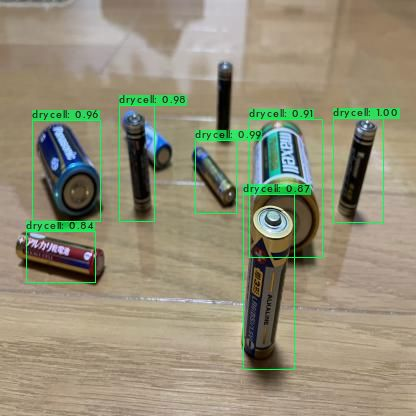

In [25]:
import cv2
from google.colab.patches import cv2_imshow

# Path to predictions image
image_path = "/content/darknet/predictions.jpg"

# Load and display the image
image = cv2.imread(image_path)
cv2_imshow(image)


1. Convert yolov3_best.weights to ONNX.
2. Optimize the ONNX model to TensorRT.
3. Use TensorRT for inference on the Jetson Nano.